In [60]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

### **Data Quality**

In [61]:
train = pd.read_csv("/content/train.csv")

In [62]:
train.shape

(699635, 23)

In [63]:
train.head()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


In [64]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 699635 non-null  int64  
 1   Age                                699635 non-null  int64  
 2   Flight Distance                    699635 non-null  int64  
 3   Inflight wifi service              699635 non-null  int64  
 4   Departure/Arrival time convenient  699635 non-null  int64  
 5   Ease of Online booking             699635 non-null  int64  
 6   Gate location                      699635 non-null  int64  
 7   Food and drink                     699635 non-null  int64  
 8   Online boarding                    699635 non-null  int64  
 9   Seat comfort                       699635 non-null  int64  
 10  Inflight entertainment             699635 non-null  int64  
 11  On-board service                   6996

In [65]:
train.isnull().mean()

,0
id,0.000000
Age,0.000000
Flight Distance,0.000000
Inflight wifi service,0.000000
Departure/Arrival time convenient,0.000000
Ease of Online booking,0.000000
Gate location,0.000000
Food and drink,0.000000
Online boarding,0.000000
Seat comfort,0.000000


In [66]:
train.shape

(699635, 23)

In [67]:
rating_cols = ['Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking',
               'Gate location','Food and drink','Online boarding','Seat comfort','Inflight entertainment',
               'On-board service','Leg room service','Checkin service','Cleanliness']

In [68]:
print("Duplicates:", train.drop("id", axis =1).duplicated().sum())
print("Rate of dissatisfaction", (train["satisfaction"] == False).mean())
print((train[rating_cols] == 0).mean()*100)

Duplicates: 0
Rate of dissatisfaction 0.5564272799388252
Inflight wifi service                1.872691
Departure/Arrival time convenient    3.680633
Ease of Online booking               2.297341
Gate location                        0.207966
Food and drink                       0.144933
Online boarding                      1.307396
Seat comfort                         0.119777
Inflight entertainment               0.145790
On-board service                     0.114488
Leg room service                     0.241983
Checkin service                      0.132784
Cleanliness                          0.135070
dtype: float64


We, can observe that out of the total customers approx 55.6 percent are unsatisfied with the services.The classes are fairly balanced, so we don't need resampling. Moreover, Ratings are 1–5 survey scores; 0 denotes "not applicable" (per dataset documentation). Zeros are concentrated in wifi, online booking, online boarding and time convenience which simply means that services were not used.

In [69]:
results = []
for c in rating_cols:
    grouped = train.groupby(train[c] == 0)["satisfaction"].agg(["mean", "count"])
    results.append({
        "Service Column": c,
        "Satisfaction 1-5": f"{grouped.loc[False, 'mean'] * 100:.1f}%",
        "Count 1-5": grouped.loc[False, 'count'],
        "satisf Rating 0": f"{grouped.loc[True, 'mean'] * 100:.1f}%",
        "Count 0": grouped.loc[True, 'count']
    })

summary_df = pd.DataFrame(results)
display(summary_df)

,Service Column,Satisfaction 1-5,Count 1-5,satisf Rating 0,Count 0
0,Inflight wifi service,43.5%,686533,88.7%,13102
1,Departure/Arrival time convenient,44.2%,673884,47.8%,25751
2,Ease of Online booking,43.7%,683562,70.8%,16073
3,Gate location,44.3%,698180,54.3%,1455
4,Food and drink,44.4%,698621,21.9%,1014
5,Online boarding,44.1%,690488,62.0%,9147
6,Seat comfort,44.4%,698797,18.4%,838
7,Inflight entertainment,44.4%,698615,14.0%,1020
8,On-board service,44.4%,698834,14.7%,801
9,Leg room service,44.4%,697942,27.0%,1693


Zero ratings split into two patterns. For wifi, online booking and online boarding, zeros mark much more satisfied passengers (88.7%, 70.8%, 62.0%), consistent with N/A. For in-flight service ratings, zeros mark very unsatisfied passengers (14-27%, ~0.1% of rows), behaving like a lowest rating; handling to be decided after comparing them with rating 1.

### **EDA**

1. Which Columns are most related to the satisfaction column?
2. If we talk about unsatisfied customers, is delay in departure/arrival overpowering the inflight experience?
3. What seperates the satisfied and unsatisfied customers within the same class.
4. significance of Type of Travel.

Talking about a customer satisfaction for a flight, it would depend on pre-flight experience, in-flight and schedule, delays. These columns are given in the dataset. Moving forward let us find out the distribution of satisfaction levels

**Class column**

In [70]:
train.groupby("Class")["satisfaction"].mean().sort_values()

,satisfaction
Class,
Eco,0.167558
Eco Plus,0.242180
Business,0.725311


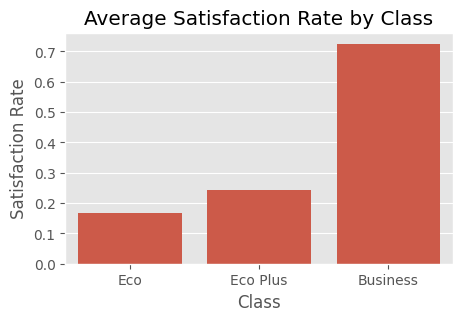

In [71]:
plt.figure(figsize=(5,3))
sns.barplot(
    data=train.groupby("Class")["satisfaction"].mean().sort_values().reset_index(),
    x="Class",
    y="satisfaction"
)
plt.title("Average Satisfaction Rate by Class")
plt.ylabel("Satisfaction Rate")
plt.show()

People travelling by business class are mostly satisfied and people travelling by Eco class are mostly unsatisfied similarly for eco plus. For business class it is obvious due to the kind of facilities provided. We need to explore more about the unsatisfied business class customers maybe there is some issue due to which customers are unsatisfied.

**Type of travel**

In [72]:
(train["Type of Travel"].value_counts(normalize = True))*100

,proportion
Type of Travel,
Business travel,71.100074
Personal Travel,28.899926


71% of the travel is business related.

In [73]:

train.groupby("Type of Travel")["satisfaction"].value_counts(normalize = True)*100

Type of Travel   satisfaction
Business travel  True            58.433663
                 False           41.566337
Personal Travel  False           90.273698
                 True             9.726302
Name: proportion, dtype: float64

In [74]:
train["Customer Type"].value_counts(normalize = True)

,proportion
Customer Type,
Loyal Customer,0.824701
disloyal Customer,0.175299


In [75]:
train.groupby("Customer Type")["satisfaction"].value_counts(normalize = True)

Customer Type      satisfaction
Loyal Customer     False           0.504855
                   True            0.495145
disloyal Customer  False           0.799054
                   True            0.200946
Name: proportion, dtype: float64

In [76]:
train[train["Arrival Delay in Minutes"]>60]["Arrival Delay in Minutes"].count()

np.int64(310)

**what is the percentage of people who were unsatisfied and got delayed?**

In [77]:
delay_label = np.where(train["Departure Delay in Minutes"] > 0, "Delayed", "Not delayed")
sat_label = np.where(train["satisfaction"], "Satisfied", "Unsatisfied")

pd.crosstab(delay_label, sat_label, normalize="all").round(3)      # share of all passengers
pd.crosstab(delay_label, sat_label, normalize="index").round(3)    # within each delay group
pd.crosstab(delay_label, sat_label, normalize="columns").round(3)  # within each satisfaction group

col_0,Satisfied,Unsatisfied
row_0,,
Delayed,0.083,0.099
Not delayed,0.917,0.901


In [78]:
delay_label = np.where(train["Arrival Delay in Minutes"] > 0, "Delayed", "Not delayed")
sat_label = np.where(train["satisfaction"], "Satisfied", "Unsatisfied")

pd.crosstab(delay_label, sat_label, normalize="all").round(3)      # share of all passengers
pd.crosstab(delay_label, sat_label, normalize="index").round(3)    # within each delay group
pd.crosstab(delay_label, sat_label, normalize="columns").round(3)  # within each satisfaction group

col_0,Satisfied,Unsatisfied
row_0,,
Delayed,0.067,0.098
Not delayed,0.933,0.902


Around 90% of the people had no delay and were unsatisfied, so delays are not the main driver of dissatisfaction.

In [79]:
train[train["Departure Delay in Minutes"]>60].groupby("satisfaction")[["Class","Customer Type"]].value_counts()

satisfaction  Class     Customer Type    
False         Eco       Loyal Customer       115
                        disloyal Customer     58
              Business  Loyal Customer        42
                        disloyal Customer     17
              Eco Plus  Loyal Customer         9
                        disloyal Customer      1
True          Business  Loyal Customer        89
              Eco       Loyal Customer        12
              Business  disloyal Customer      7
              Eco       disloyal Customer      2
              Eco Plus  Loyal Customer         1
Name: count, dtype: int64

Similarly for departure, most of the dissatisfaction is caused amongst the people travelling by Business class.
Let us find out the proportion in the case of delayed departure/arrival and dissatisfaction in business class.

### **Cleanliness Column**

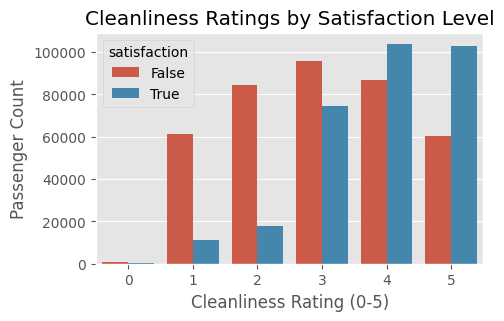

In [80]:
plt.figure(figsize = (5,3))
sns.countplot(data=train, x="Cleanliness", hue="satisfaction")
plt.title("Cleanliness Ratings by Satisfaction Level")
plt.xlabel("Cleanliness Rating (0-5)")
plt.ylabel("Passenger Count")
plt.show()

In [81]:
train["Checkin service"].value_counts(normalize = True)

,proportion
Checkin service,
4,0.299573
3,0.286116
5,0.210896
2,0.107083
1,0.095004
0,0.001328


#### **Confounding Check**

In [82]:
pd.crosstab(train["Class"], train["Type of Travel"], normalize = "all")*100

Type of Travel,Business travel,Personal Travel
Class,,
Business,48.349782,0.563151
Eco,20.240840,26.555561
Eco Plus,2.509451,1.781214


In [83]:
pt = train.pivot_table(index=["Class", "Type of Travel"], values="satisfaction",
                       aggfunc=["mean", "count"]).round(3)
pt

mean        count
                         satisfaction satisfaction
Class    Type of Travel                           
Business Business travel        0.732       338272
         Personal Travel        0.112         3940
Eco      Business travel        0.260       141612
         Personal Travel        0.097       185792
Eco Plus Business travel        0.346        17557
         Personal Travel        0.095        12462

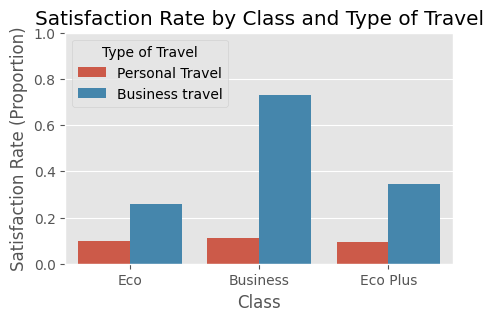

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure satisfaction is handled numerically/boolean for plotting
sat_col = train["satisfaction"].astype(str).str.lower().str.strip() == "true"
plot_data = train.copy()
plot_data["Satisfaction Rate"] = sat_col.astype(int)
plt.figure(figsize=(5,3))
sns.barplot(
    data=plot_data,
    x="Class",
    y="Satisfaction Rate",
    hue="Type of Travel",
    errorbar=None
)

plt.title("Satisfaction Rate by Class and Type of Travel")
plt.ylabel("Satisfaction Rate (Proportion)")
plt.ylim(0, 1.0)
plt.show()

So, type of travel is a more stronger factor. Satisfaction levels depend upon the interaction of class and type of travel. Business related travels are more satisfied despite of the class.

###**Categorical Columns**

Columns are confounded, so analysis shall be done accordingly.

**What is the size of each passenger group?**

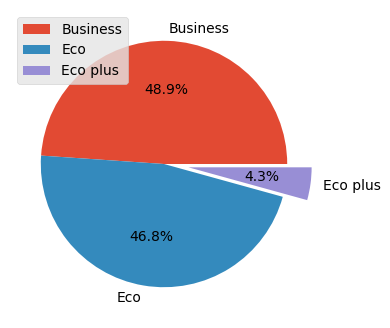

In [85]:
plt.figure(figsize = (7,4))
plt.style.use("ggplot")
explode = (0,0,0.2)
labels = ["Business", "Eco", "Eco plus"]
plt.pie(train["Class"].value_counts(normalize = True), autopct = "%1.1f%%", explode = explode, labels = labels)
plt.legend()
plt.show()

**Satisfaction rate in each group?**

In [86]:
train.groupby("Class")["satisfaction"].value_counts(normalize = True)

Class     satisfaction
Business  True            0.725311
          False           0.274689
Eco       False           0.832442
          True            0.167558
Eco Plus  False           0.757820
          True            0.242180
Name: proportion, dtype: float64

In [87]:
train.groupby("Customer Type")["satisfaction"].value_counts(normalize = True)

Customer Type      satisfaction
Loyal Customer     False           0.504855
                   True            0.495145
disloyal Customer  False           0.799054
                   True            0.200946
Name: proportion, dtype: float64

In [88]:
train.groupby("Gender")["satisfaction"].value_counts(normalize = True)

Gender  satisfaction
Female  False           0.562006
        True            0.437994
Male    False           0.550908
        True            0.449092
Name: proportion, dtype: float64

Roughly similar so no such pattern observed due to gender.

#### **Where is the dissatisfaction clustered?**

In [89]:
unhappy = train[train["satisfaction"] == False]
(unhappy.groupby(["Class", "Type of Travel"]).size()/len(unhappy)) * 100

Class     Type of Travel 
Business  Business travel    23.247863
          Personal Travel     0.898802
Eco       Business travel    26.917564
          Personal Travel    43.092146
Eco Plus  Business travel     2.947885
          Personal Travel     2.895740
dtype: float64

In [90]:
happy = train[train["satisfaction"] == True]
(happy.groupby(["Class", "Type of Travel"]).size()/len(happy)) * 100

Class     Type of Travel 
Business  Business travel    79.838177
          Personal Travel     0.142103
Eco       Business travel    11.865412
          Personal Travel     5.811709
Eco Plus  Business travel     1.959470
          Personal Travel     0.383129
dtype: float64

Most of unhappy passengers are the Eco-class passengers , there type of travel is personal. Happiest are the passengers who travel busiiness class.

**Which service rating is lowest for the unhappy passengers?**

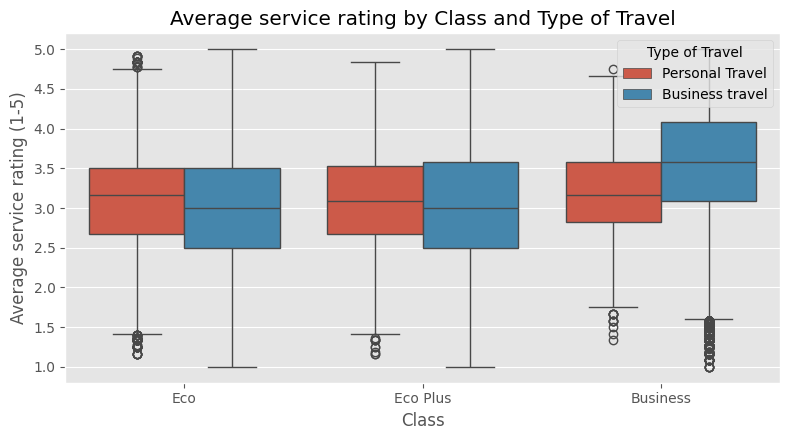

In [91]:
train["avg_service"] = train[rating_cols].replace(0, np.nan).mean(axis=1)

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=train, x="Class", y="avg_service", hue="Type of Travel",
            order=["Eco", "Eco Plus", "Business"])
plt.ylabel("Average service rating (1-5)")
plt.title("Average service rating by Class and Type of Travel")
plt.tight_layout(); plt.show()

In [92]:

train.columns

Index(['id', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender',
       'Customer Type', 'Type of Travel', 'Class', 'satisfaction',
       'avg_service'],
      dtype='object')

**Which rating matters the most?**

In [93]:
rating_cols = ['Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking',
               'Gate location','Food and drink','Online boarding','Seat comfort','Inflight entertainment',
               'On-board service','Leg room service','Baggage handling','Checkin service','Cleanliness']

In [94]:
r = train[rating_cols]
rank = r.corrwith(train["satisfaction"].astype(float), method="spearman").sort_values(ascending=False)
print(rank.round(2))

Online boarding                      0.60
Inflight entertainment               0.43
Seat comfort                         0.41
On-board service                     0.35
Cleanliness                          0.33
Leg room service                     0.33
Inflight wifi service                0.29
Baggage handling                     0.28
Checkin service                      0.24
Food and drink                       0.21
Ease of Online booking               0.19
Gate location                        0.02
Departure/Arrival time convenient   -0.05
dtype: float64


In [95]:
rating_cols1 = ['Inflight wifi service','Departure/Arrival time convenient','Ease of Online booking',
               'Gate location']
r = train[rating_cols1].replace(0, np.nan)
rank = r.corrwith(train["satisfaction"].astype(float), method="spearman").sort_values(ascending=False)
print(rank.round(2))

Inflight wifi service                0.33
Ease of Online booking               0.22
Gate location                        0.03
Departure/Arrival time convenient   -0.05
dtype: float64


**What seperates a happy customer from an unhappy customer?**

In [96]:
group = train[(train["Class"] == "Business") & (train["Type of Travel"] == "Business travel")]
g = group[rating_cols].replace(0, np.nan).groupby(group["satisfaction"]).mean().T
g["difference"] = g[True] - g[False]
print(g.sort_values("difference", ascending=False).round(2))

satisfaction                       False  True  difference
Online boarding                     2.99  4.33        1.34
Inflight entertainment              2.88  4.19        1.31
Seat comfort                        3.17  4.29        1.11
Cleanliness                         2.89  3.94        1.05
On-board service                    3.14  4.17        1.03
Leg room service                    3.12  4.12        1.00
Baggage handling                    3.45  4.26        0.82
Checkin service                     3.11  3.89        0.78
Inflight wifi service               2.52  3.15        0.64
Food and drink                      3.00  3.59        0.59
Ease of Online booking              2.87  3.17        0.30
Departure/Arrival time convenient   2.89  3.13        0.24
Gate location                       2.99  3.07        0.08


Better online boarding facilities, Inflight entertainment, seat comfort, Cleanliness, on board service, leg room. Happy customers had a better experience.

### **Final Insights from EDA**

1. Class and Type of Travel interact. Among business travelers, satisfaction rises from 25% (Eco) to 36% (Eco Plus) to 73% (Business). Personal travelers are 8-12% satisfied in every class.
2. Dissatisfaction is concentrated. Eco personal (43%), Eco business (27%) and Business/Business (23%) hold about 93% of unsatisfied passengers.
3. Delays are a secondary factor. About 9% of passengers were delayed, and only about 10% of unsatisfied passengers had an arrival delay. Delayed passengers are about 10 points less satisfied.
4. Customer Type: loyal 49.5% satisfied vs disloyal 20.1%.

**Verdict** : Satisfaction is driven mainly by who is flying and why: the effect of Class exists only for business travelers (25% to 73%), while personal travelers are 8-12% satisfied in every class. Among service ratings, online boarding is the strongest correlate (ρ = 0.61), followed by inflight entertainment and seat comfort. Delays play a secondary role. These are associations from survey data in which ratings and satisfaction come from the same respondent, so service quality and individual rating tendencies cannot be separated.

###**Handling missing Values**

<Axes: >

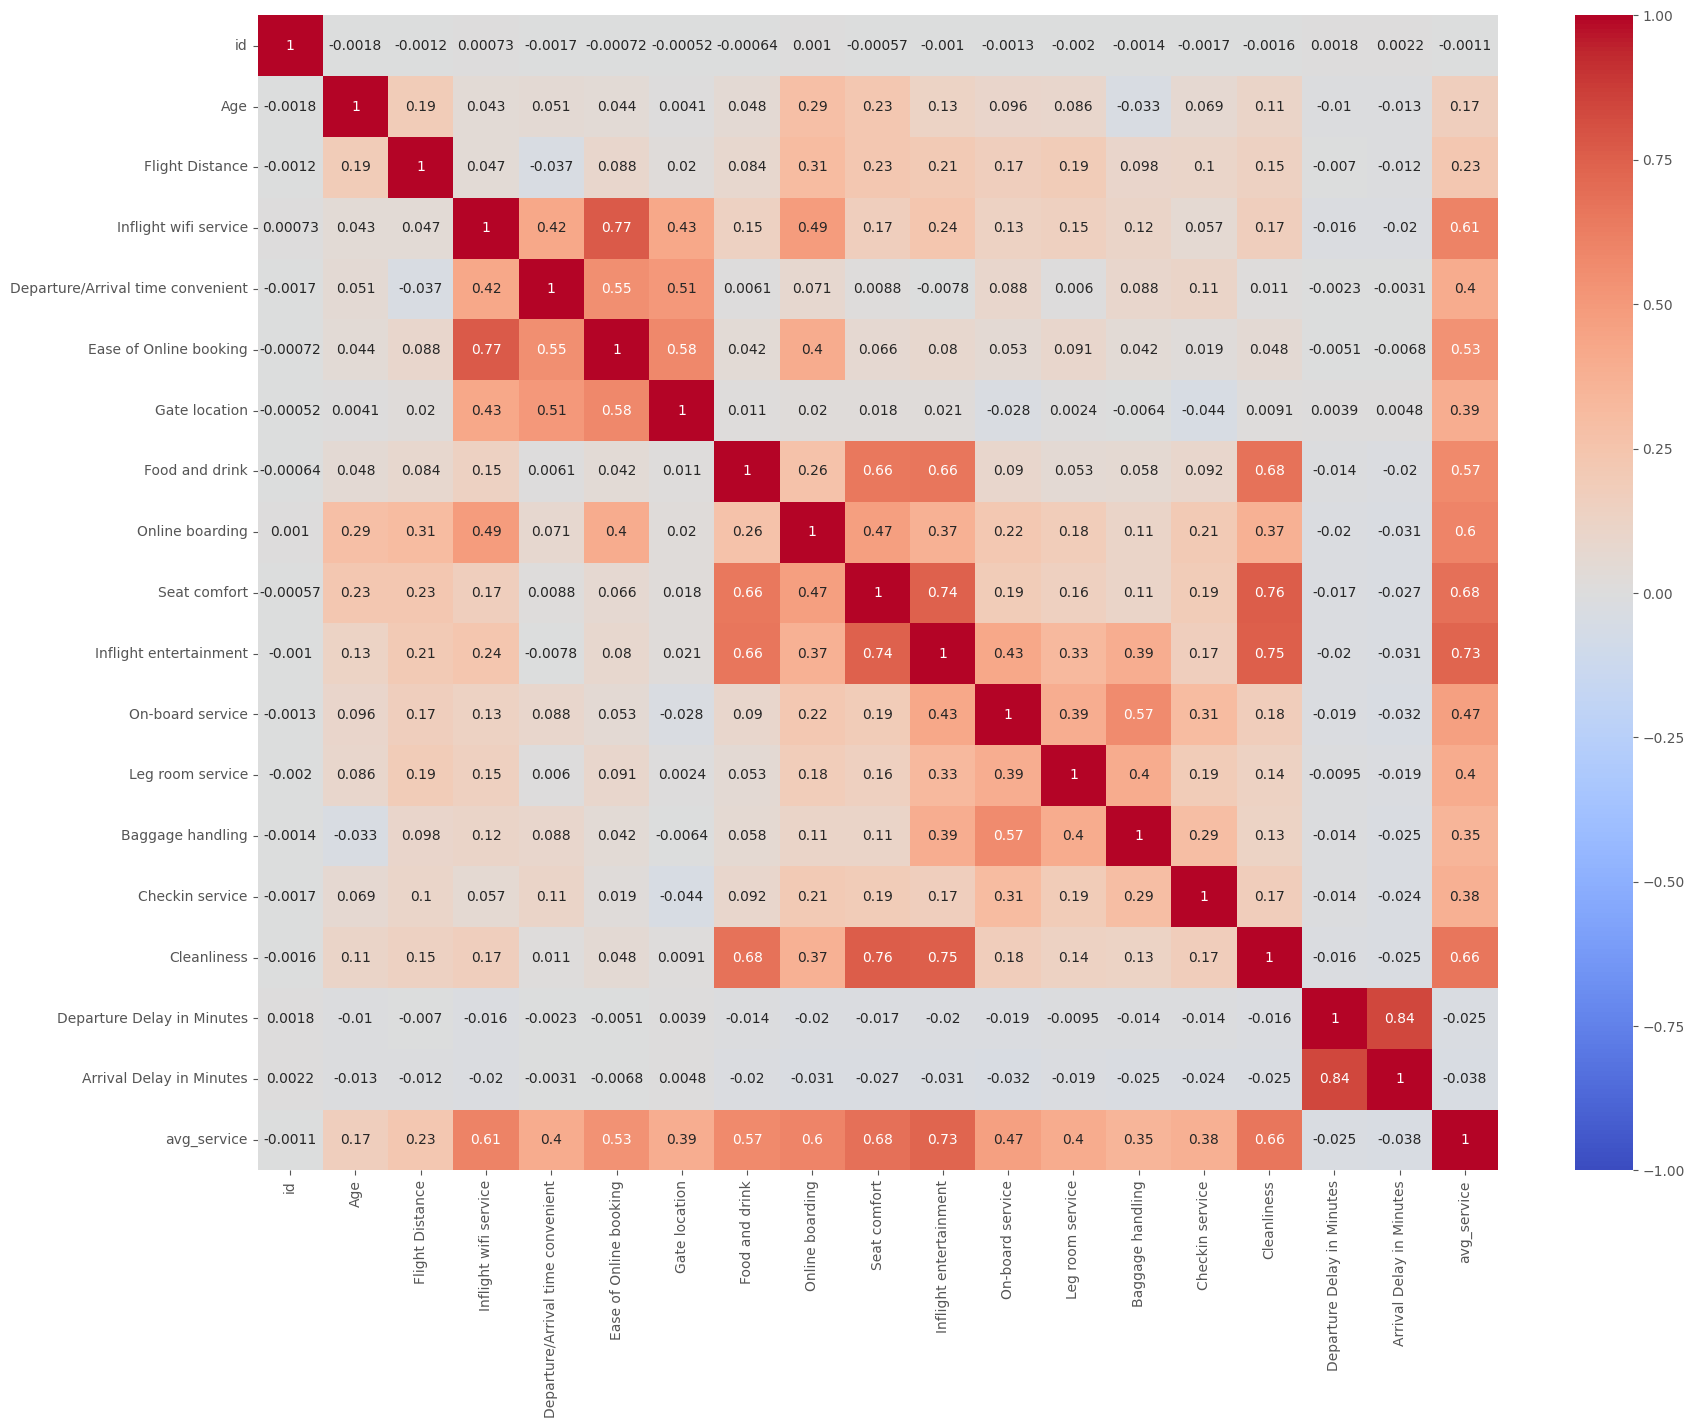

In [97]:
num = train.select_dtypes(include = "number")
plt.figure(figsize = (20,15))
sns.heatmap(num.corr(), annot = True, cmap = "coolwarm", vmax = +1, vmin = -1)

In [98]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, roc_curve, precision_recall_curve, precision_score, f1_score

In [99]:
train.shape

(699635, 24)

In [100]:
train = train.dropna()

In [101]:
x = train.drop(["id","satisfaction"], axis = 1)
y = train["satisfaction"]

In [102]:
x_train, x_val, y_train, y_val = train_test_split(x,y, test_size = 0.2, random_state=2)

In [103]:
train.columns

Index(['id', 'Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender',
       'Customer Type', 'Type of Travel', 'Class', 'satisfaction',
       'avg_service'],
      dtype='object')

In [104]:
num_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

tnf = ColumnTransformer(transformers = [
    ("tnf1", OneHotEncoder(sparse_output = False, drop = "first"), cat_cols),
    ("tnf2", StandardScaler(), num_cols)
    ], remainder = "passthrough")

#### **Decision Tree Classifier**

In [105]:
step2 = DecisionTreeClassifier()

pipe = Pipeline([
    ("tnf", tnf),
    ("step2", step2)
])

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_val)
print("Accuracy score", accuracy_score(y_val, y_pred))
print("Precision score", precision_score(y_val, y_pred))
print("Recall score", recall_score(y_val, y_pred))
print("F1 score", f1_score(y_val, y_pred))
print("roc_auc score", roc_auc_score(y_val, y_pred))

Accuracy score 0.8653668790082149
Precision score 0.8465386218616732
Recall score 0.8508080759252993
F1 score 0.8486679792662836
roc_auc score 0.863893653426355


**Random Forest Classifier**

In [106]:
step2 = RandomForestClassifier()

pipe = Pipeline([
    ("tnf", tnf),
    ("step2", step2)
])

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_val)
print("Accuracy score", accuracy_score(y_val, y_pred))
print("Precision score", precision_score(y_val, y_pred))
print("Recall score", recall_score(y_val, y_pred))
print("F1 score", f1_score(y_val, y_pred))
print("roc_auc score", roc_auc_score(y_val, y_pred))

Accuracy score 0.9240360623154523
Precision score 0.9258229021789522
Recall score 0.9009845152350107
F1 score 0.9132348497840058
roc_auc score 0.9217034441278898


**Xgboost**

In [107]:
pipe1 = Pipeline([
    ("tnf", tnf),
    ("step2", XGBClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=8,
        subsample=0.85, colsample_bytree=0.8,
        tree_method="hist", random_state=2, n_jobs=-1))
])

pipe1.fit(x_train, y_train)
y_pred = pipe1.predict(x_val)
proba = pipe1.predict_proba(x_val)[:, 1]

print("Accuracy ", accuracy_score(y_val, y_pred))
print("Precision", precision_score(y_val, y_pred))
print("Recall   ", recall_score(y_val, y_pred))
print("F1       ", f1_score(y_val, y_pred))
print("ROC AUC  ", roc_auc_score(y_val, proba))

Accuracy  0.9254659717306909
Precision 0.9257164528575669
Recall    0.9046099805030534
F1        0.9150415216735801
ROC AUC   0.9577390214198688


**Lightgbm**

In [108]:
from lightgbm import LGBMClassifier
pipe = Pipeline([
    ("tnf", tnf),
    ("step2", LGBMClassifier(
        n_estimators=500, learning_rate=0.1, num_leaves=63,
        subsample=0.85, subsample_freq=1, colsample_bytree=0.8,
        random_state=2, n_jobs=-1, verbose=-1))
])

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_val)

print("Accuracy score", accuracy_score(y_val, y_pred))
print("Precision score", precision_score(y_val, y_pred))
print("Recall score", recall_score(y_val, y_pred))
print("F1 score", f1_score(y_val, y_pred))
print("roc_auc score", roc_auc_score(y_val, y_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy score 0.9254445230894622
Precision score 0.9260640668063967
Recall score 0.9041588114919192
F1 score 0.9149803512319207
roc_auc score 0.9232905922563441


**Feature Importance**

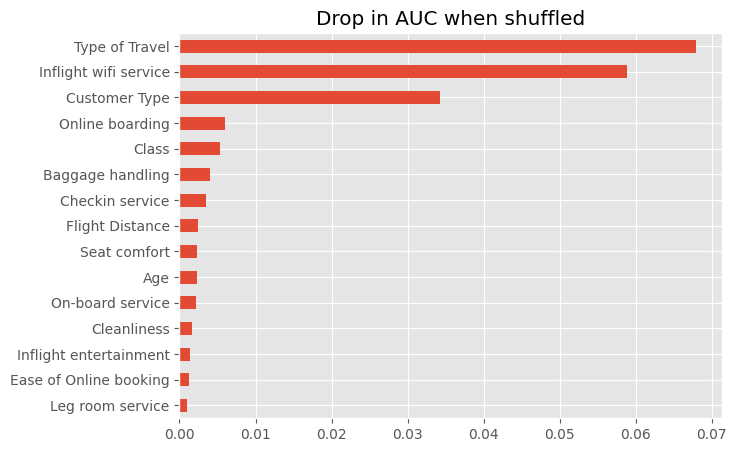

In [109]:
from sklearn.inspection import permutation_importance

idx = np.random.RandomState(2).choice(len(x_val), 30000, replace=False)
res = permutation_importance(pipe1, x_val.iloc[idx], y_val.iloc[idx],
                             scoring="roc_auc", n_repeats=5, random_state=2, n_jobs=-1)
imp = pd.Series(res.importances_mean, index=x_val.columns).sort_values()
imp.tail(15).plot(kind="barh", figsize=(7, 5), title="Drop in AUC when shuffled")
plt.show()

**ROC-AUC Curve**

In [110]:
from sklearn.metrics import RocCurveDisplay

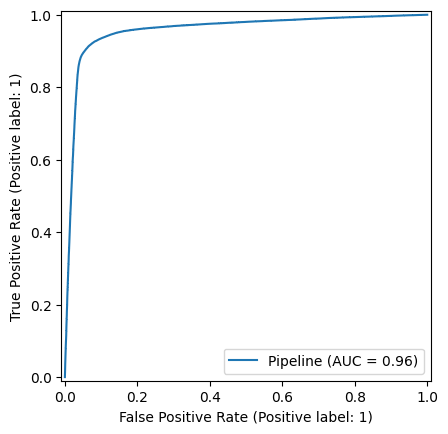

In [111]:
# for xgboost
plt.style.use("default")
RocCurveDisplay.from_estimator(pipe1, x_val, y_val)
plt.show()

**False positive rate** : wrongly classifying label 1 as 0. So, rate is number of false postives (false alarms) out of all the positive predictions.

The curve shows that model has 96% chance of correctly classifying the classes.

### **Final submission**

In [112]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

In [113]:
x_train = train.drop(["id","satisfaction"], axis = 1)
y_train = train["satisfaction"]
x_test = test.drop("id", axis = 1)

In [114]:
pipe1 = Pipeline([
    ("tnf", tnf),
    ("step2", XGBClassifier(
        n_estimators=500, learning_rate=0.1, max_depth=8,
        subsample=0.85, colsample_bytree=0.8,
        tree_method="hist", random_state=2, n_jobs=-1))
])

pipe1.fit(x_train, y_train)
y_pred = pipe1.predict(x_test)
proba = pipe1.predict_proba(x_test)

In [115]:
proba

array([[0.79406625, 0.20593376],
       [0.09178156, 0.90821844],
       [0.09937465, 0.90062535],
       ...,
       [0.52453065, 0.47546935],
       [0.9673393 , 0.03266073],
       [0.97637665, 0.02362334]], dtype=float32)

In [116]:
submission = pd.DataFrame({"id":test["id"], "satisfaction": proba[:,1]})
submission.to_csv("submission.csv", index = False)